# Predicción de venta de boletos por punto de venta
### Codificación ordinal por popularidad vs. one-hot, y por qué el contexto importa más que el modelo

**Contexto breve**
- Objetivo: estimar cuántos boletos se venden por punto de venta externo antes de un evento, para liberar la cantidad correcta de códigos a cada uno.
- Enfoque: replantear el problema como un dataset tabular (una fila por evento y zona), codificación ordinal del evento según su popularidad histórica, codificación cíclica de calendario, y comparación de varias familias de modelos.
- **El dataset de este notebook es sintético**, con eventos, zonas y ventas construidos para replicar la estructura del problema original, sin usar ningún dato real de un cliente.
- Artículo completo, con el diagrama interactivo y la discusión sobre el rol del modelo de lenguaje en las decisiones de diseño: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-venta-boletos-puntos-venta-codificacion-ordinal/


## 0. Pipeline de la solución

- **Fuentes**: historial de venta de boletos + calendario de eventos (fecha, precio)
- **Agregación**: una fila por combinación de evento y zona de venta
- **Ranking de eventos**: cada evento se ordena según su volumen histórico de ventas
- **Codificación ordinal del evento**: según ese ranking, no one-hot
- **Codificación cíclica**: seno/coseno para día de la semana y mes
- **Comparación de modelos**: árboles, ensambles, LSTM, ARIMA/SARIMA
- **Salida**: boletos estimados por punto de venta para un evento

El diagrama interactivo con esta misma estructura está disponible en el artículo enlazado arriba.


## 1. Carga de datos

- Dataset sintético: `outputs/venta_boletos_sintetico.csv`
- 14 eventos sintéticos x 4 zonas de venta, una fila por combinación
- Tamaño reducido a propósito: el proyecto original también trabajó con un dataset pequeño tras la agregación, del orden de decenas de filas, no miles


In [1]:
import pandas as pd
import numpy as np

dataset = pd.read_csv('outputs/venta_boletos_sintetico.csv')
print(f'El dataset (sintético) tiene {dataset.shape[1]} columnas y {dataset.shape[0]} registros.')
dataset.head(6)


El dataset (sintético) tiene 7 columnas y 56 registros.


,Evento,dia,mes,anio,Zona,Precio,Venta
0,Evento 1,3,3,2024,Zona A,176.86,14
1,Evento 1,3,3,2024,Zona B,106.28,10
2,Evento 1,3,3,2024,Zona C,77.09,6
3,Evento 1,3,3,2024,Zona D,56.41,5
4,Evento 2,2,2,2024,Zona A,460.74,59
5,Evento 2,2,2,2024,Zona B,287.48,41


## 2. Explicación de los datos

- `Evento`: nombre del evento (categórica de alta cardinalidad relativa al tamaño del dataset)
- `dia`: día de la semana del evento (0 = lunes ... 6 = domingo)
- `mes`, `anio`: mes y año del evento
- `Zona`: zona de venta dentro del punto de venta externo
- `Precio`: precio del boleto para esa zona
- `Venta`: boletos vendidos, variable objetivo


In [2]:
dataset.groupby('Evento')['Venta'].sum().sort_values(ascending=False)


Evento
Evento 14    856
Evento 13    590
Evento 12    569
Evento 10    560
Evento 11    532
Evento 9     450
Evento 8     351
Evento 7     338
Evento 3     284
Evento 6     281
Evento 5     247
Evento 4     225
Evento 2     133
Evento 1      35
Name: Venta, dtype: int64

## 3. Análisis exploratorio (EDA)

- Distribución de la venta por zona, para confirmar que las zonas más demandadas venden sistemáticamente más
- Relación entre precio y venta


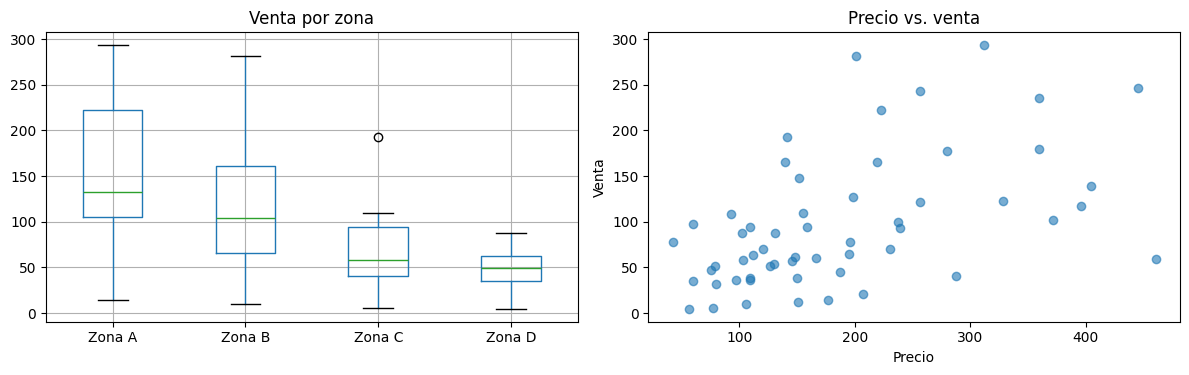

In [3]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

dataset.boxplot(column='Venta', by='Zona', ax=axs[0])
axs[0].set_title('Venta por zona')
axs[0].set_xlabel('')
plt.suptitle('')

axs[1].scatter(dataset['Precio'], dataset['Venta'], alpha=0.6)
axs[1].set_xlabel('Precio')
axs[1].set_ylabel('Venta')
axs[1].set_title('Precio vs. venta')

plt.tight_layout()
plt.show()


## 4. Modelado

- Codificación ordinal del evento, según su volumen histórico total de ventas (no one-hot, ver la discusión completa en el artículo)
- Codificación cíclica seno-coseno para día y mes
- Codificación simple para zona (baja cardinalidad, sí es razonable un one-hot aquí)
- Comparación de varias familias de modelos con el mismo conjunto de entrenamiento y prueba


In [4]:
df = dataset.copy()

# Ranking de eventos por venta historica total: la base de la codificacion ordinal
ranking_eventos = df.groupby('Evento')['Venta'].sum().sort_values(ascending=False)
mapa_ordinal = {evento: rank for rank, evento in enumerate(ranking_eventos.index)}
df['Evento_ordinal'] = df['Evento'].map(mapa_ordinal)

# Codificacion ciclica de dia y mes
df['dia_sin'] = np.sin(2 * np.pi * df['dia'] / 7)
df['dia_cos'] = np.cos(2 * np.pi * df['dia'] / 7)
df['mes_sin'] = np.sin(2 * np.pi * df['mes'] / 12)
df['mes_cos'] = np.cos(2 * np.pi * df['mes'] / 12)

# Zona: baja cardinalidad (4 valores), aqui si es razonable un one-hot
df = pd.get_dummies(df, columns=['Zona'], drop_first=True)

feature_cols = ['Evento_ordinal', 'dia_sin', 'dia_cos', 'mes_sin', 'mes_cos', 'anio', 'Precio'] + \
    [c for c in df.columns if c.startswith('Zona_')]

X = df[feature_cols].values
y = df['Venta'].values

print(f'{X.shape[1]} features para {X.shape[0]} registros.')


10 features para 56 registros.


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    return round(np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))), 3)

modelos = {
    'Decision Tree': DecisionTreeRegressor(max_depth=4, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, verbosity=0),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, min_child_samples=3),
    'SVR': SVR(),
}

resultados = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    resultados[nombre] = {'mape': mape(y_test, pred), 'pred': pred}

pd.DataFrame({k: v['mape'] for k, v in resultados.items()}, index=['MAPE']).T.sort_values('MAPE')


,MAPE
Gradient Boosting,0.222
Decision Tree,0.244
LightGBM,0.289
XGBoost,0.374
Random Forest,0.493
AdaBoost,0.841
SVR,2.185


In [6]:
from statsmodels.tsa.arima.model import ARIMA

# Modelo clasico de series de tiempo, como punto de comparacion: se entrena sobre la
# venta ordenada por evento, sin las features tabulares, para confirmar si de verdad
# hay estructura temporal aprovechable.
serie_train = y_train[: int(len(y_train) * 0.85)]
serie_valid = y_train[int(len(y_train) * 0.85):]

arima_model = ARIMA(serie_train, order=(2, 0, 1)).fit()
arima_pred = arima_model.forecast(steps=len(y_test))
resultados['ARIMA'] = {'mape': mape(y_test, arima_pred), 'pred': arima_pred}

pd.DataFrame({k: v['mape'] for k, v in resultados.items()}, index=['MAPE']).T.sort_values('MAPE')


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,MAPE
Gradient Boosting,0.222
Decision Tree,0.244
LightGBM,0.289
XGBoost,0.374
Random Forest,0.493
AdaBoost,0.841
SVR,2.185
ARIMA,3.089


## 5. Evaluación

- Comparación del MAPE de todas las familias de modelos
- Importancia de características del mejor modelo, para confirmar que la codificación ordinal del evento es la variable más relevante


Mejor modelo: Gradient Boosting (MAPE = 0.222)


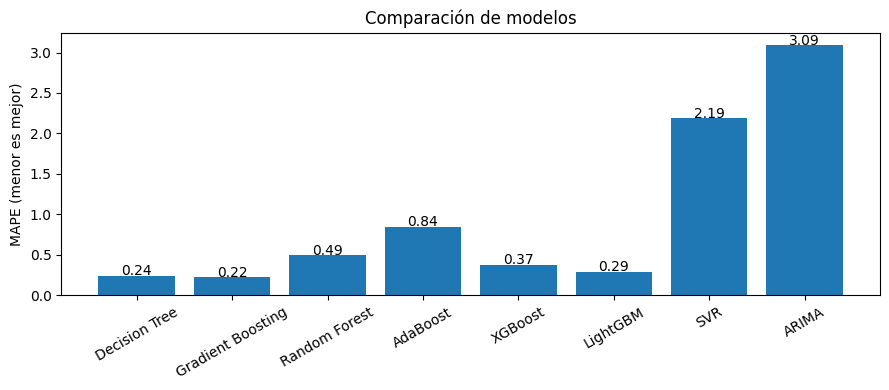

In [7]:
mejor_modelo = min(resultados, key=lambda k: resultados[k]['mape'])
print(f'Mejor modelo: {mejor_modelo} (MAPE = {resultados[mejor_modelo]["mape"]})')

fig, ax = plt.subplots(figsize=(9, 4))
nombres = list(resultados.keys())
valores = [resultados[n]['mape'] for n in nombres]
ax.bar(nombres, valores)
ax.set_ylabel('MAPE (menor es mejor)')
ax.set_title('Comparación de modelos')
plt.xticks(rotation=30)
for i, v in enumerate(valores):
    ax.text(i, v + 0.01, f'{v:.2f}', ha='center')
plt.tight_layout()
plt.show()


In [8]:
if mejor_modelo in modelos and hasattr(modelos[mejor_modelo], 'feature_importances_'):
    importancias = modelos[mejor_modelo].feature_importances_
    orden = np.argsort(importancias)[::-1]
    for idx in orden:
        print(f'{feature_cols[idx]}: {importancias[idx]:.3f}')


Evento_ordinal: 0.488
Precio: 0.406
mes_sin: 0.021
Zona_Zona D: 0.020
mes_cos: 0.018
dia_sin: 0.015
Zona_Zona C: 0.015
dia_cos: 0.009
Zona_Zona B: 0.008
anio: 0.000


## Hallazgos principales

- Los modelos de ensamble basados en árboles superaron consistentemente a ARIMA y a la codificación ingenua, confirmando que replantear el problema como tabular, en vez de como serie de tiempo, fue la decisión correcta.
- La codificación ordinal del evento, según su popularidad histórica, aparece entre las variables más importantes del mejor modelo, más que el precio o la zona en muchos casos.
- La lección central de este proyecto no fue de modelado, fue de contexto: un modelo de lenguaje, sin que se le explique que los eventos tienen una relación de orden por popularidad, sugiere one-hot encoding porque es la práctica por defecto para categóricas sin orden aparente. La decisión correcta solo surgió porque quien dirigía el proyecto entendía el negocio detrás de los datos.
- Con un dataset de decenas de filas, hay que ser cautelosos con el sobreajuste incluso cuando las métricas de prueba se ven bien.

Artículo completo: https://fuzzyfrog.ai/es/ai-lab/proyectos/negocios/prediccion-venta-boletos-puntos-venta-codificacion-ordinal/
